# 数据预处理

# 主题：单变量异常值检测

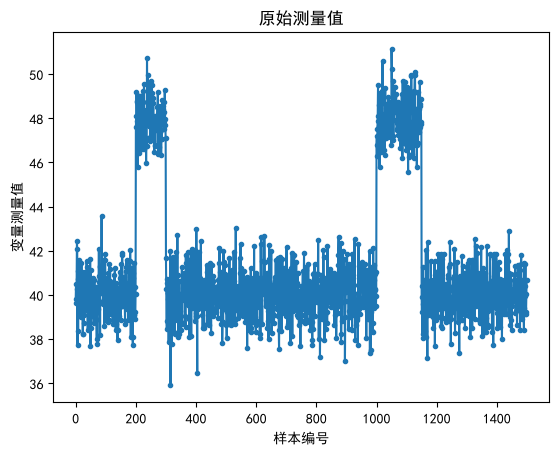

In [5]:
# 生成含异常值的数据
import numpy as np

X = np.random.normal(40, 1, (1500,1))
X[200:300] = X[200:300] +8; X[1000:1150] = X[1000:1150] + 8

# 绘图
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC', 'WenQuanYi Micro Hei']
plt.plot(X, '.-')
plt.xlabel('样本编号'), plt.ylabel('变量测量值')
plt.title('原始测量值')
plt.show()

估计均值 =  41.35346348077728
估计标准差 =  3.1359308026686303


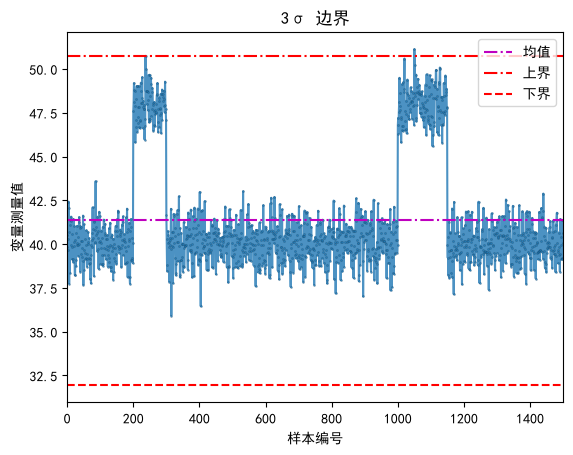

In [6]:
# 3σ 准则
# 位置与离散度
mu = np.mean(X)
sigma = np.std(X)

# 均值与标准差
print('估计均值 = ', mu)
print('估计标准差 = ', sigma)

# 绘图
plt.figure()
plt.plot(X, '.-', alpha=0.8, markeredgecolor='k', markeredgewidth=0.1, ms=3)
plt.hlines(mu, 0, 1500, colors='m', linestyles='dashdot', label='均值') 
plt.hlines(mu+3*sigma, 0, 1500, colors='r', linestyles='dashdot', label='上界') 
plt.hlines(mu-3*sigma, 0, 1500, colors='r', linestyles='dashed', label='下界') 

plt.xlabel('样本编号'), plt.ylabel('变量测量值')
plt.xlim((0,1500))
plt.title('3σ 边界')
plt.legend(loc='upper right')
plt.show()

估计稳健位置 =  40.26936515283578
估计稳健离散度 =  [0.86634217]


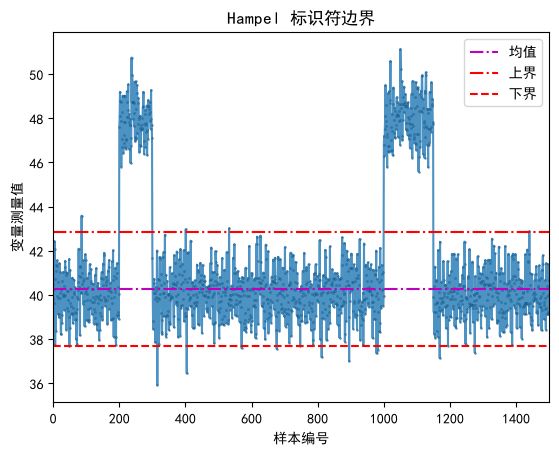

In [7]:
# Hampel 标识符
# 计算中位数与 MAD
from scipy import stats

median = np.median(X)
sigma_MAD = stats.median_abs_deviation(X) # 默认缩放因子 1.4826 已内置

# 中位数与 sigma_MAD
print('估计稳健位置 = ', median)
print('估计稳健离散度 = ', sigma_MAD)

# 绘图
plt.figure()
plt.plot(X, '.-', alpha=0.8, markeredgecolor='k', markeredgewidth=0.1, ms=3)
plt.hlines(median, 0, 1500, colors='m', linestyles='dashdot', label='均值') 
plt.hlines(median+3*sigma_MAD, 0, 1500, colors='r', linestyles='dashdot', label='上界') 
plt.hlines(median-3*sigma_MAD, 0, 1500, colors='r', linestyles='dashed', label='下界') 

plt.xlabel('样本编号'), plt.ylabel('变量测量值')
plt.xlim((0,1500))
plt.title('Hampel 标识符边界')
plt.legend(loc='upper right')
plt.show()